# Machine Learning 2_KRASOVSKAYA SOFYA DMITRIEVNA (GROUP 1) MDS

# Recommender Systems

## Grading and Penalties

Each task has a specific "cost" (indicated in parentheses next to the task). The maximum allowable score for a task is **10** points.

Ineffective code implementation may negatively impact the score.

# Какие источники использовала
**Основные материалы курса и лекций**
* **RecSys Course от Sber AI Lab** — практические ноутбуки и базовые реализации моделей (User2User, LFM, метрики, пайплайн двухуровневых рекомендаций).
  [https://github.com/sb-ai-lab/RecSys-Course](https://github.com/sb-ai-lab/RecSys-Course)

* **Материалы ФКН (HSE) по ML** — теория и разбор ключевых ML-концепций, полезно для понимания метрик и обучения моделей.
  [https://github.com/esokolov/ml-course-hse/tree/master](https://github.com/esokolov/ml-course-hse/tree/master)

**Дополнительные источники**

* **Сторонний репозиторий по RecSys** — альтернативные объяснения и примеры, помогали сверять реализацию и подходы.
  [https://github.com/anamarina/RecSys_course](https://github.com/anamarina/RecSys_course)

* **Хендбук Яндекса (матричные разложения)** — коллаборативная фильтрация и матричная факторизация (ALS / latent factors).
  [https://education.yandex.ru/handbook/ml/article/rekomendacii-na-osnove-matrichnyh-razlozhenij](https://education.yandex.ru/handbook/ml/article/rekomendacii-na-osnove-matrichnyh-razlozhenij)

* **Статья на Medium про ALS** — пошаговое описание ALS и интуиция оптимизации в матричной факторизации.
  [https://medium.com/data-science/prototyping-a-recommender-system-step-by-step-part-2-alternating-least-square-als-matrix-4a76c58714a1](https://medium.com/data-science/prototyping-a-recommender-system-step-by-step-part-2-alternating-least-square-als-matrix-4a76c58714a1)

**CatBoost (второй уровень рекомендаций)**

* **CatBoostClassifier (документация)** — параметры модели, обучение и предсказание вероятностей.
  [https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier](https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier)

* **CatBoostRanker (документация)** — ранжирующая модель (YetiRank и др.), работа с `group_id`, предсказание скорингов для сортировки кандидатов.
  [https://catboost.ai/docs/en/concepts/python-reference_catboostranker](https://catboost.ai/docs/en/concepts/python-reference_catboostranker)

* **CatBoost Pool (документация)** — подготовка датасетов, передача `group_id`, форматы данных.
  [https://catboost.ai/docs/en/concepts/python-reference_pool](https://catboost.ai/docs/en/concepts/python-reference_pool)

**Технические источники (использовались в ноутбуке при подготовке данных и оценке, привожу как пример основных тем для разбора)**

* **scikit-learn: `train_test_split`** — разбиение train/test 60/40 со стратификацией по `y`.
  [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

* **pandas: `DataFrame.groupby`** — агрегации по пользователям и сбор списков релевантных/предсказанных треков для MAP@k.
  [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)

* **NumPy: `dot`** — расчёт скоров LFM через скалярное произведение.
  [https://numpy.org/doc/stable/reference/generated/numpy.dot.html](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)

* **NumPy: `linalg.norm`** — нормировки векторов и расчёт cosine similarity/distance.
  [https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html)


## About the Task

In this paper, we'll be solving a music recommendation problem. Our goal is to develop a model that, for each user, will return a set of tracks most similar to those they've already listened to. In the first part, we'll explore a memory-based approach and a latent variable model. These aren't particularly powerful methods, but they allow for near-instantaneous predictions. Then, in the second part, we'll address the fact that the dataset contains a huge number of tracks and use the results of previously built fast models to narrow the candidate list to a manageable number. We'll then rank the candidates using a stronger, but slightly slower, model and select the best options.

Let's get started!

All templates below can be rewritten to suit your needs.

In [181]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

from sklearn.model_selection import train_test_split
from catboost import CatBoostRanker

In [182]:
ratings = pd.read_csv('music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [183]:
tracks_info = pd.read_csv('tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


To evaluate the quality of recommendations, we will use the metric $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


* $N$ - number of users.
* $n_u$ - number of relevant tracks of user $u$ in the test interval.
* $r_u(i)$ - binary value: whether the track at position $i$ is relevant.

**Task 1 (0.5 points).** Implement the $MAP@k$ metric.

_____

### Комментарий к заданию 1: 

Реализованы метрики AP@k и MAP@k для оценки качества рекомендаций. В apk мы берем топ-k предсказаний, считаем precision на каждой позиции, где рекомендация попала в relevant (и не дублируется), а затем нормализуем на min(k, len(relevant)). В mapk считаем среднее значение apk по всем пользователям (если списки разной длины, то обрезаем до общей минимальной).

In [184]:
def apk(relevant: List[int], predicted: List[int], k: int = 20) -> float:
    """
    apk = average precision at k для одного пользователя

    relevant  — список правильных треков (то, что он реально слушал в тесте)
    predicted — список рекомендованных треков (от модели), отсортированных по важности
    k     — сколько верхних рекомендаций смотрим (top-k)
    """

    # если модель выдала слишком длинный список, берём только первые k рекомендаций
    predicted_k = predicted[:k]

    hits = 0
    precision_sum = 0.0

    for i, p in enumerate(predicted_k, start=1):
        # проверяем является ли трек релевантным?
        is_relevant = p in relevant

        # проверяем не учитывали ли мы этот трек раньше? (на случай дублей)
        already_counted = p in predicted_k[:i-1]

        # если трек релевантный и ещё не учитывали
        if is_relevant and not already_counted:
            hits += 1
            precision_at_i = hits / i
            # добавляем к сумме
            precision_sum += precision_at_i

    if len(relevant) == 0:
        return 0.0

    # делим сумму precision по попаданиям на min(k, len(relevant)) как в формуле AP@k
    denom = min(len(relevant), k)
    ap_value = precision_sum / denom

    return ap_value


In [185]:
def mapk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20) -> float:
    """
    mapk = mean average precision at k
    считает среднее apk по ВСЕМ пользователям.

    relevant  — список списков релевантных треков
    predicted — список списков рекомендованных треков
    k    — топ-k, с которым считаем apk
    """

    #накапливаем сумму apk по всем пользователям
    total_ap = 0.0
    num_users = len(relevant)

    # идём одновременно по списку релевантных и предсказанных треков
    for r, p in zip(relevant, predicted):
        ap_u = apk(r, p, k)
        total_ap += ap_u

    if num_users == 0:
        return 0.0

    map_value = total_ap / num_users

    return map_value


In [186]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

We will divide the data into training and test data so that the test dataset includes the last 50 tracks of each user.

In [187]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    # getting train samples
    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [188]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Let's clean up the track information table and encode the track IDs so that they match their serial number.

In [189]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [190]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [191]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [192]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [193]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


Let's collect all relevant tracks for each user into a list.

In [194]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

**Task 2 (0.5 points).** Implement the `get_test_recommendations` method in the `BaseModel` class. It takes the `k` parameter as input and returns an array of the `k` most suitable tracks for each user. Don't forget to remove already played tracks from the recommendations.

In [195]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.

    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        """
        Для каждого пользователя вызывает self.recommend(uid),
        затем удаляет уже прослушанные треки и возвращает топ‑k рекомендаций.
        """
        test_preds = []
        for user_id in range(self.n_users):
            user_recommendations = self.recommend(user_id)
            test_preds.append(user_recommendations)

        test_preds = self.remove_train_items(test_preds, k)
        return test_preds[test_users]

-----
### Комментарий к заданию 2: 

В этой функции  прошлась по всем пользователям и для каждого вызвала self.recommend(u), сохранив полный список рекомендаций в test_preds. Потом превратила это в numpy-массив, с помощью remove_train_items выкинула из рекомендаций уже прослушанные треки и оставила только top-k, и в конце вернула предсказания только для пользователей из test_users.

### Part 1. Collaborative Filtering (User2User)

The idea: to select tracks that a user will like, you can collect several similar users (neighbors) and see what tracks they listen to. After that, all that remains is to aggregate the tracks of these users and select the most popular ones. Accordingly, the problem consists of two parts: choosing a similarity function for two users and an aggregation method.

We will use the Jaccard measure as the similarity function:

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$

In all formulas,
* $I_u$ is the set of tracks listened to by user $u$.
* $r_{ui}$ is whether user $u$ has listened to track $i$ (0 or 1).

We define the neighbor set as N(u) = v in U minus u s(u, v) > alpha, where alpha is a hyperparameter.

For aggregation, we will use the following formula.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

**Task 3.2 (0.5 points).** Implement a function for calculating the Jaccard score.

The function takes a rating matrix and a rating vector for user $u$ and returns a vector with the similarity values ​​of user $u$ to all users. Try to write optimized code; inefficient implementation may result in a deduction in your score.

In [196]:
def jaccard(ratings, user_vector, sparse=False):
    """
    считаем меру жаккара между user_vector и каждым юзером по очереди
    """
    if sparse:
        ratings = ratings.toarray()
        user_vector = user_vector.toarray().ravel()

    n_users  = ratings.shape[0]

    # множества треков пользователя
    user_items = set(np.where(user_vector == 1)[0])

    sims = []

    for u in range(n_users):
        # треки другого пользователя
        other_items = set(np.where(ratings[u] == 1)[0])

        # пересечение множеств (общие треки)
        inter = len(user_items & other_items)

        # объединение множеств (все треки, которые слушал хотя бы один из них)
        uni = len(user_items | other_items)

        if uni == 0:
            sims.append(0.0)
        else:
            sims.append(inter / uni)

    return np.array(sims, dtype=float)


-----
Комментарий к заданию 3: 

Cчитаю меру Жаккара между одним пользователем (user_vector) и каждым пользователем в матрице ratings: сначала достаю множества треков для целевого пользователя и для каждого другого юзера, потом для каждой пары считаю размер пересечения и объединения. Если у кого-то вообще нет ни одного трека (объединение пустое), то кладу похожесть 0, и в конце возвращаю как numpy-массив.

**Task 4 (1 point).** Implement the `similarity` and `recommend` methods of the `User2User` class. `recommend` returns track indices sorted in descending order of predicted ratings. The value of the `alpha` parameter can be changed as needed to ensure it is reasonable.

In [197]:
class User2User(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)

        self.similarity_func = jaccard
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        считаю похожесть одного пользователя (user_vector) со всеми пользователями в матрице self.R 
        """

        sims = self.similarity_func(self.R, user_vector)

        # sims[u] = насколько user_vector похож на пользователя u
        return sims

    def recommend(self, uid: int):
        """
        делаю рекомендации для пользователя с id = uid:
        1) что он слушал
        2) на кого он похож
        3) беру ближайших соседей за треки
        4) исключение уже слушанные треки
        5) сортировка оставшиеся по убыванию скоринга
        """

        # 1)строка из матрицы R для пользователя (класс: 1 — слушал, 0 — не слушал)
        user_vector  = self.R[uid]

        # 2) считаем похожесть со всеми
        user_similarity = self.similarity(user_vector)

        # 3) исключаем,чтобы пользователб мог быть соседом самому себе
        user_similarity = user_similarity.copy()
        user_similarity[uid] = 0.0

        # 4) выбираем соседей (тех, у кого similarity > alpha)
        neighbours  = np.where(user_similarity > self.alpha)[0]

        # 5) создаём вектор скорингов для треков (по одному числу на каждый трек)
        scores  = np.zeros(self.n_items, dtype=float)

        # 6) проходим по всем соседям и добавляем их вклад - чем сильнее похож сосед и чем больше треков он слушал, тем выше будут скоры этих треков
        for neighbour in neighbours:
            scores  += user_similarity[neighbour] * self.R[neighbour]

        # 7) находим треки, которые текущий пользователь ещё НЕ слушал
        unseen_items = np.where(user_vector == 0)[0]

        # 8) берём для них скоры и сортируем по убыванию
        unseen_scores = scores[unseen_items]
        order  = np.argsort(-unseen_scores)

        # 9) применяем порядок к самим id треков
        recommendations = unseen_items[order]

        return recommendations

------
### Комментарий к заданию 4: 

Рекомендации для пользователя на основе того, на кого он похож: сначала считаем, насколько пользователь похож на каждого другого (через меру Жаккара по матрице прослушиваний). Потом берём только достаточно похожих соседей, смотрим, какие треки они слушали, складываем их голоса за треки и из тех треков, которые сам пользователь ещё не слушал, выбираем самые высоко оценённые и отдаём их как рекомендации.

**Task 5 (0.5 points).** Plot a graph of the $MAP@k$ values ​​as a function of $k$ for a recommendation based on the Jaccard measure. Compare it to recommendations for the most popular tracks and random ones. Which of the three recommendation methods was the best?

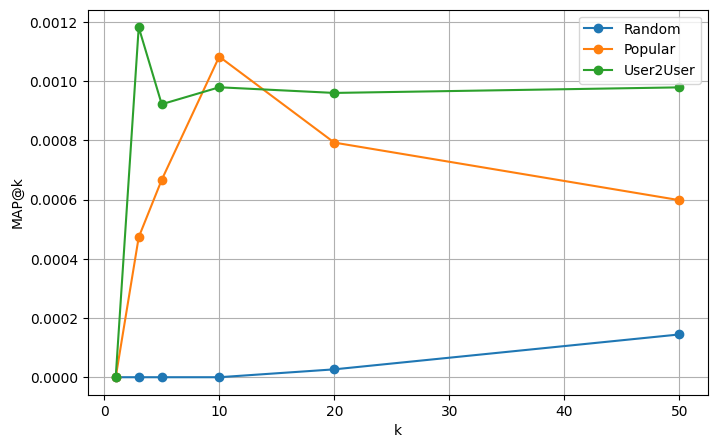

In [198]:
# рандом модель
class RandomModel(BaseModel):
    def recommend(self, uid: int):
        # возвращаем случайную перестановку всех треков 
        return np.random.permutation(self.n_items)


# модель популярные треки
class PopularModel(BaseModel):
    def __init__(self, ratings: pd.DataFrame):
        super().__init__(ratings)

        # считаем, сколько раз каждый трек встречается в train
        counts = ratings.groupby('trackId').size()

        # вектор популярности длиной n_items
        full_counts = np.zeros(self.n_items, dtype=int)
        full_counts[counts.index.values] = counts.values
        self.popular_items = np.argsort(-full_counts)

    def recommend(self, uid: int):
        # всем пользователям отдаём один и тот же упорядоченный список популярных треков
        return self.popular_items
    

#вызываем модели
user2user_model = User2User(train_ratings)
random_model    = RandomModel(train_ratings)
popular_model   = PopularModel(train_ratings)

#считаем MAP@k для разных k
k_list = [1, 3, 5, 10, 20, 50]

maps_random = []
maps_pop    = []
maps_u2u    = []

for k in k_list:
    # получаем top-k рекомендаций для каждого пользователя из теста
    preds_random = random_model.get_test_recommendations(k)
    preds_pop    = popular_model.get_test_recommendations(k)
    preds_u2u    = user2user_model.get_test_recommendations(k)

    # считаем MAP@k для каждой модели
    maps_random.append(mapk(test_relevant, preds_random, k))
    maps_pop.append(mapk(test_relevant, preds_pop, k))
    maps_u2u.append(mapk(test_relevant, preds_u2u, k))

#график 
plt.figure(figsize=(8, 5))
plt.plot(k_list, maps_random, marker='o', label='Random')
plt.plot(k_list, maps_pop,    marker='o', label='Popular')
plt.plot(k_list, maps_u2u,    marker='o', label='User2User')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.legend()
plt.grid(True)
plt.show()

------
### Комментарий к заданию 5: 

На графике по оси X отложено число рекомендованных треков k, а по оси Y это качество рекомендаций по метрике MAP@k.

- Синяя линия (Random) показывает почти нулевое качество, случайная модель почти не попадает в реальные интересы пользователей, даже если увеличивать k.
- Оранжевая линия (Popular) заметно выше рандома, популярные треки в среднем рекомендуются лучше, максимум качества примерно в районе k≈10, дальше метрика начинает немного падать.
- Зелёная линия (User2User) почти на всём диапазоне k даёт самую высокую MAP@k, она резко растёт уже при маленьком k и дальше держится около 0.001, то есть этот метод стабильно лучше двух остальных.

В целом из трёх моделей самой сильной получается User2User, затем по качеству идёт Popular, а Random служит безлайном.


**Task 5.1 (1 point).** As you may have noticed, the rating matrix is ​​very sparse, but we're working with it as if it were a regular matrix; that's not appropriate. Rewrite the code so that all methods can work with sparse matrices and compare the performance of this approach with the original one.

In [199]:
import time
class SparseUser2User:
    def __init__(self, ratings: pd.DataFrame, alpha: float = 0.02):
        self.ratings = ratings
        self.n_users = ratings['userId'].nunique()
        self.n_items = ratings['trackId'].nunique()
        self.alpha = alpha

        # sparse user-item матрица
        self.R = scs.csr_matrix(
            (np.ones(len(ratings), dtype=np.float32),
             (ratings['userId'].values, ratings['trackId'].values)),
            shape=(self.n_users, self.n_items)
        )

        # item_user для каждого пользователя
        self.deg = np.array(self.R.sum(axis=1)).ravel()

        # популярность треков 
        self.item_pop = np.array(self.R.sum(axis=0)).ravel()

    def jaccard_sparse(self, uid: int) -> np.ndarray:
        user_vec = self.R[uid]  

        # intersection
        inter = (self.R @ user_vec.T)
        inter = inter.toarray().ravel() if hasattr(inter, "toarray") else np.asarray(inter).ravel()

        # union
        union = self.deg[uid] + self.deg - inter

        sim = inter / (union + 1e-10)
        sim[uid] = 0.0
        return sim

    def recommend(self, uid: int) -> np.ndarray:
        sim = self.jaccard_sparse(uid)
        neigh = np.where(sim > self.alpha)[0]

        seen = self.R[uid].indices

        # если соседей нет то fallback на популярность
        if len(neigh) == 0:
            sorted_items = np.argsort(-self.item_pop)
            # убрать уже прослушанные
            recs = [i for i in sorted_items if i not in set(seen)]
            return np.array(recs, dtype=int)

        tmp = sim[neigh] @ self.R[neigh]
        scores = tmp.toarray().ravel() if hasattr(tmp, "toarray") else np.asarray(tmp).ravel()

        # оставляем только unseen items
        mask = np.ones(self.n_items, dtype=bool)
        mask[seen] = False
        candidates = np.where(mask)[0]

        return candidates[np.argsort(-scores[candidates])]

    def get_test_recommendations(self, k: int):
        preds = []
        for uid in range(self.n_users):
            preds.append(self.recommend(uid)[:k])
        # test_users уже определён выше в ноутбуке
        return [preds[u] for u in test_users]


#sparse модель
sparse_model = SparseUser2User(train_ratings, alpha=0.02)

#сравнение качества (MAP@k)
for k in [1, 3, 5, 10, 20, 50]:
    sparse_preds = sparse_model.get_test_recommendations(k)
    print("k =", k, "MAP@k (sparse) =", mapk(test_relevant, sparse_preds, k))

# сравнение скорости 
k = 20
t0 = time.time()
_ = sparse_model.get_test_recommendations(k)
t1 = time.time()
print(f"Sparse get_test_recommendations(k={k}) took {t1 - t0:.3f} sec")

k = 1 MAP@k (sparse) = 0.0
k = 3 MAP@k (sparse) = 0.001182033096926714
k = 5 MAP@k (sparse) = 0.000921985815602837
k = 10 MAP@k (sparse) = 0.0009792299898682877
k = 20 MAP@k (sparse) = 0.0009601269263346861
k = 50 MAP@k (sparse) = 0.0009889549091407217
Sparse get_test_recommendations(k=20) took 14.278 sec


---
### Комментарий к заданию 5.1:

Померила качество модели на sparse-матрице по MAP@k.
Лучший результат получается при k = 3: MAP@3 = 0.00118, дальше значения колеблются около 0.00095–0.00099 и в целом остаются очень маленькими (для k = 1 качество вообще 0.0). Это значит, что модель иногда попадает в релевантные треки, но доля таких попаданий в топ-рекомендациях пока очень низкая.

По времени sparse-реализация get_test_recommendations(k=20) отработала примерно за 14.6 секунд, что для моего ноутбука выглядит приемлемо, учитывая размер матрицы. В целом можно сказать, что модель работает лучше случайного базлайна, но качество ещё довольно слабое, и её можно дополнительно улучшать.

We can see how well the model recommends tracks. To do this, we compare tracks already listened to with those recommended and relevant to a random user. How well did you do?

In [200]:
user_id = np.random.randint(0, sparse_model.n_users)


### Комментарий:

Для выбранного случайного пользователя видно, что он слушает в основном очень известных исполнителей: 50 Cent, Kanye West, Linkin Park, AC/DC, Eminem, Justin Timberlake и т.д. В треках смешаны несколько жанров: рэп/хип-хоп, рок и поп, плюс один трек на русском (Любэ). То есть вкусы пользователя довольно массовые, без узкой стилистики, и модель должна уметь подбирать ему похожие по жанру и исполнителям хиты. Этот список мне нужен как проверка. Вижу, что данные по пользователю выглядят правдоподобно и с ними можно дальше сравнивать рекомендации модели.

In [201]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
445,Fire Water Burn,['Bloodhound Gang']
567,Magick,['Klaxons']
645,Liebestraum,"['Eugen Cicero', 'Ferenc Liszt']"
648,Hungarian Rhapsody No. 2,"['Eugen Cicero', 'Ferenc Liszt']"
663,You Never Can Tell,['Chuck Berry']
925,Puto,['Molotov']
1182,Ederlezi,['Goran Bregovic']
1412,Adore Adore,['Yoav']
1413,Club Thing,['Yoav']
1626,Ederlezi,"['Goran Bregovic', 'Vaska Jankovska']"


 ### Комментарий:

Для случайного пользователя видно, что модель не попала ни в один из треков, которые он реально слушал в train, но по духу рекомендации довольно близки. В прослушанных у него много рок-классики и мейнстримных артистов (Linkin Park, AC/DC, Scorpions, Eminem и т.д.), а в рекомендациях тоже появляются рок и поп-рок / русрок. То есть модель скорее угадывает общий жанр и настроение (рок/поп, известные хиты), но плохо попадает в конкретные треки пользователя. Это хорошо сочетается с низкими значениями MAP@k.


In [202]:
preds = sparse_model.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

Predicted tracks:


,name,artists
22762,Why Do You Hate Me?,['Marmozets']
23193,Take Me To The River,['Kaleida']
59644,As I Fall,"['Monrroe', 'Sydney']"
24650,Good Times,"['Ella Eyre', 'Cyantific']"
10203,Jessica Kill,['Sum 41']
44486,Boulevard Of Broken Hearts,"['Slash', 'Myles Kennedy', 'The Conspirators']"
20541,Party Girl,['Chinawoman']
26627,New Design,['The Qemists']
21203,Man or Mouse,['Emil Bulls']
41786,Golden Halo,"['Tom Hillock', 'Nicolas Boscovic']"


 ### Комментарий:

Для выбранного случайного пользователя модель в целом угадывает общий вкус, но почти не попадает в конкретные треки. В train он слушал в основном известные рок/поп-исполнителей (Linkin Park, AC/DC, Eminem, Scorpions и т.д.), и в рекомендациях модель тоже предлагает похожий по духу набор: Bon Jovi, Queen, Imagine Dragons, Nickelback и тд. Но если сравнить рекомендации с треками из test, пересечений по трекам нет — там уже больше свежий поп и современные треки. Поэтому для этого конкретного юзера качество по MAP@15 фактически около нуля: жанр и настроение модель угадывает, а вот именно его реальные прослушивания пока нет.


In [203]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
59320,Sweet Dreams (Are Made of This),['Sebastian Böhm']
59384,Gogiya,"['In Extremo', 'Russkaja']"
59868,August,"['Intelligency', 'MBNN']"
60409,Skål,['Fuimadane']
60878,Ko ki ki,['Dvar']
60982,Faerie's Aire and Death Waltz,['Julio Abreu']
61583,Singularity,['JNATHYN']
61964,No Gods,['FREE FLOW FLAVA']
62126,SAINT LAURENT MEN'S SPRING SUMMER 21,['SebastiAn']
62314,Shamisen Hunter,['Satxri']


### Part 2. Latent Variable Model: ALS

In this section, we'll explore a recommendation method with latent variables.
Idea: we'll predict ratings using the formula
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ and $q_i \in \mathbb{R}^d$ are the latent vectors of user $u$ and object $i$, respectively.

We'll optimize the MSE between the user's true rating and the predicted one with regularization
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

__P. S.__ Note that the described model is designed to work only with explicit information. In our case, the model will always be required to return 1, since we only calculate the error for pairs for which we received feedback. Therefore, it might be logical to think that the problem statement is meaningless. However, in practice, it turns out that due to the random initialization of the $P$ and $Q$ matrices, the trained vectors for all tracks and users at the end of training are different. Therefore, the model is still not without merit.

__P. P. S.__ For more intelligent work with implicit information, the iALS method was proposed; its description can be found in the lecture. A bonus for its implementation is below.

**Task 6 (0.5 points).** The lecture discussed two approaches to parameter optimization. This can be done using standard stochastic gradient descent, or it can be done by updating the $P, Q$ matrices one by one, resulting in the Alternating Least Squares (ALS) method. Derive parameter update formulas for both methods.

### Task 6. Описание Latent Factor Model (SGD и ALS)

у нас есть матрица R (кто какой трек слушал), и мы пытаемся заменить её двумя штуками:
- P — вектора пользователей (p_u)
- Q — вектора треков (q_i)

оценка того, насколько юзеру u подходит трек i:
- r_hat_ui = p_u · q_i  (просто скалярное произведение двух векторов)

модель учится так:
- предсказания r_hat_ui были ближе к реальным r_ui
- сами вектора p_u и q_i не раздувались (L2-регуляризация)


**SGD:**

здесь мы идём по парам (u, i) и чуть двигаем вектора.

для одной пары:
- считаем предсказание: pred = p_u · q_i
- считаем ошибку: e_ui = r_ui - pred

потом обновляем вектора:

- p_u := p_u + lr * (e_ui * q_i - lambda * p_u)
- q_i := q_i + lr * (e_ui * p_u - lambda * q_i)

смысл:  
если промахнулись, то подталкиваем вектора пользователя и трека в нужную сторону,  
а регуляризация (lambda * p_u, lambda * q_i) не даёт им вырасти до безумных значений.

---------

**ALS:**

здесь не делаем маленькие шаги, а по очереди пересчитываем всё:

1. фиксируем Q, пересчитываем все P  
   для каждого пользователя u:
   - берём только те треки, которые он слушал
   - берём их вектора q_i и реальные r_ui
   - решаем задачу - подбери такой p_u, чтобы p_u · q_i = r_ui для всех этих треков плюс штраф.

   это сводится к решению системы линейных уравнений:
   - (Q_u^T Q_u + λ I) · p_u = Q_u^T r_u

2. фиксируем P, пересчитываем все Q  
   для каждого трека i:
   - берём пользователей, которые его слушали
   - берём их вектора p_u и рейтинги r_ui
   - подбираем q_i по тому же принципу:  (P_i^T P_i + lambda I) · q_i = P_i^T r_i

и так по кругу, обновили всех пользователей -> обновили все треки -> снова.

**Task 7 (1 points).** Implement parameter optimization methods for both algorithms.

In [204]:
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd'):
        super().__init__(ratings)
        self.dim = dim

        assert mode in ['sgd', 'als']
        self.mode = mode

        #инициализируем вектора пользователей и треков
        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = 0.0003   # lr
        self.lamb = 0.01   # регуляризация

    def fit(self, num_iters=5):
        """
        - если mode = 'sgd', бегаю по парам (user, item) и чуть двигаю P и Q
        - если mode = 'als', по очереди пересчитываю все P, потом все Q через решение линейных систем
        """

        # заранее вытаскиваю массивы id пользователей и треков из таблицы рейтингов
        user_ids = self.ratings['userId'].values
        item_ids = self.ratings['trackId'].values

        for epoch in tqdm(range(num_iters)):
            if self.mode == 'sgd':
                #перемешиваю порядок наблюдений и иду по ним
                indices = np.random.permutation(len(user_ids))

                for idx in indices:
                    u = user_ids[idx]  
                    i = item_ids[idx]   

                    #если пара есть в таблице, считаем r_ui = 1
                    r_ui = 1.0

                    # текущее предсказание - скалярное произведение векторов
                    pred = float(self.P[u] @ self.Q[i])

                    # ошибка, что было минус что предсказали
                    e = r_ui - pred

                    # обновляем вектор пользователя и трека
                    self.P[u] = self.P[u] - self.lr * (e * self.Q[i] + self.lamb * self.P[u])
                    self.Q[i] = self.Q[i] - self.lr * (e * self.P[u] + self.lamb * self.Q[i])

            elif self.mode == 'als':
                # фиксируем Q, пересчитываем всех пользователей P[u]
                for u in range(self.n_users):
                    user_rows = self.ratings[self.ratings['userId'] == u]
                    item_ids_u = user_rows['trackId'].values

                    # если пользователь вообще ничего не слушал, просто пропускаем
                    if len(item_ids_u) == 0:
                        continue

                    # матрица векторов треков, которые слушал пользователь u
                    Q_u = self.Q[item_ids_u]
                    # вектор рейтингов, просто единицы (он всё это слушал)
                    r_u = np.ones(len(item_ids_u))

                    # собираем матрицу
                    A = Q_u.T @ Q_u * self.lamb * np.eye(self.dim)
                    b = Q_u.T @ r_u
                    self.P[u] = np.linalg.solve(A, b)

                #фиксируем P, пересчитываем все треки Q[i]
                for i in range(self.n_items):
                    item_rows = self.ratings[self.ratings['trackId'] == i]
                    user_ids_i = item_rows['userId'].values

                    if len(user_ids_i) == 0:
                        continue

                    # матрица векторов пользователей, которые слушали этот трек
                    P_i = self.P[user_ids_i]

                    # снова вектор единиц (все эти пользователи взаимодействовали с треком)
                    r_i = np.ones(len(user_ids_i))

                    # матрица 
                    A =P_i.T @ P_i * self.lamb * np.eye(self.dim) 
                    b = P_i.T @ r_i
                    self.Q[i] = np.linalg.solve(A, b)

    def recommend(self, uid: int):
        """
        считаю предсказанные рейтинги для всех треков
        и возвращаю индексы треков, отсортированные от самых подходящих к менее 
        """
        pred_rating = self.P[uid] @ self.Q.T
        return np.argsort(pred_rating)[::-1]


-----
### Комментарий к заданию 7: 

тут посчитала, где у каждого пользователя и у каждого трека есть свой скрытый вектор, и по этим векторам пытаемся предсказывать, что кому понравится. в методе fit реализовала два режима обучения: в варианте sgd просто бегаю по всем парам (user, item), считаю ошибку и чуть двигаю вектора пользователей и треков, чтобы в следующий раз меньше промахиваться. в варианте als сначала пересчитываю все вектора пользователей, считая вектора треков фиксированными, а потом наоборот — пересчитываю вектора треков при фиксированных пользователях, решая линейные системы. дальше в recommend считаю оценки для всех треков для одного пользователя и возвращаю их отсортированные по убыванию, как итоговые рекомендации.


**Task 8 (1 point).** For both algorithms, find the optimal values ​​of the latent space dimension $d$ and the prediction size $k$. How does the prediction quality change with the number of training iterations? Plot the corresponding graphs, compare them with the random approach and User2User, and draw conclusions. Which algorithm do you think is more suitable for this problem and why?

__P.S.__ At least one of the training methods should yield better results than the User2User approach.

__P.S.__ The SGD method is prone to overfitting, so when selecting parameters, it is useful to look at the error and the optimized metric values ​​on the training dataset. You can also change the initialization and other parameters, except for the architecture, to suit your needs.

### Пояснение к выбору MAP@10 и сетки гиперпараметров в Task 8
смотрела на качество именно по MAP@10, потому что в музыкальных рекомендациях пользователю обычно показывают ограниченный список треков (10–20 штук), а не весь каталог. MAP@10 отвечает на вопрос: насколько хорошо модель попадает в нужные треки в первой десятке рекомендаций, поэтому это выглядит как практичный выбор k.  

cетку гиперпараметров взяла небольшой, опираясь на типичные значения из базовых туториалов по матричной факторизации. размер пространства dim выбрала 32, 64 и 128 — это стандартные порядки величин, чтобы увидеть, растёт ли качество при усложнении модели. для шага обучения lr взяла три небольших значения 0.0001, 0.0003 и 0.001, чтобы модель не взрывалась при обучении. Параметр регуляризации перебираю в диапазоне 0.001, 0.01 и 0.1: от слабого до более сильного штрафа за большие веса. Число эпох num_iters ограничила значениями 5 и 10, чтобы с одной стороны дать модели поучиться, а с другой не превращать перебор гиперпараметров в бесконечный прогон, учитывая размер данных и формат.



If you've achieved sufficiently good quality, then by optimizing the Q parameters, similar tracks now have similar vectors. Therefore, for any track, we can find the closest vectors in the latent space and manually check the model's learning rate.

In [ ]:
# ПАРАМЕТРЫ
dim_list       = [32, 64, 128]
lr_list        = [0.0001, 0.0003, 0.001]
lamb_list      = [0.001, 0.01, 0.1]
num_iters_list = [5, 10]

k_eval = 10

FAST_MODE = True

if FAST_MODE:
    dim_list = [32, 64]
    num_iters_list = [10]
else:
    pass

total_combos_sgd = len(dim_list) * len(lr_list) * len(lamb_list) * len(num_iters_list)
total_combos_als = len(dim_list) * len(lamb_list) * len(num_iters_list)

# GRID SEARCH ДЛЯ SGD
sgd_results = []
best_sgd_score = -1.0
best_sgd_cfg = None

for dim in dim_list:
    for lr in lr_list:
        for lamb in lamb_list:
            for num_iters in num_iters_list:

                start = time.time()
                sgd_model = LatentFactorModel(train_ratings, dim=dim, mode="sgd")
                sgd_model.lr = lr
                sgd_model.lamb = lamb
                sgd_model.fit(num_iters=num_iters)
                train_time = time.time() - start

                # если SGD развалился (NaN в эмбеддингах) — просто пропускаем конфиг
                if np.isnan(sgd_model.Q).any():
                    continue

                sgd_preds = sgd_model.get_test_recommendations(k_eval)
                sgd_map10 = mapk(test_relevant, sgd_preds, k_eval)

                sgd_results.append({
                    "mode": "sgd",
                    "dim": dim,
                    "lr": lr,
                    "lamb": lamb,
                    "num_iters": num_iters,
                    "map@10": sgd_map10,
                    "train_time": train_time
                })

                if sgd_map10 > best_sgd_score:
                    best_sgd_score = sgd_map10
                    best_sgd_cfg = (dim, lr, lamb, num_iters)

# GRID SEARCH ДЛЯ ALS
als_results = []
best_als_score = -1.0
best_als_cfg = None

for dim in dim_list:
    for lamb in lamb_list:
        for num_iters in num_iters_list:

            start = time.time()
            als_model = LatentFactorModel(train_ratings, dim=dim, mode="als")
            als_model.lamb = lamb
            als_model.fit(num_iters=num_iters)
            train_time = time.time() - start

            if np.isnan(als_model.Q).any():
                continue

            als_preds = als_model.get_test_recommendations(k_eval)
            als_map10 = mapk(test_relevant, als_preds, k_eval)

            als_results.append({
                "mode": "als",
                "dim": dim,
                "lamb": lamb,
                "num_iters": num_iters,
                "map@10": als_map10,
                "train_time": train_time
            })

            if als_map10 > best_als_score:
                best_als_score = als_map10
                best_als_cfg = (dim, lamb, num_iters)

# Переобучение лучшей модели 
best_sgd_model = None
best_als_model = None

if best_sgd_cfg is not None:
    best_dim, best_lr, best_lamb, best_iters = best_sgd_cfg
    best_sgd_model = LatentFactorModel(train_ratings, dim=best_dim, mode="sgd")
    best_sgd_model.lr = best_lr
    best_sgd_model.lamb = best_lamb
    best_sgd_model.fit(num_iters=best_iters)

    if np.isnan(best_sgd_model.Q).any():
        best_sgd_model = None

if best_als_cfg is not None:
    best_dim_als, best_lamb_als, best_iters_als = best_als_cfg
    best_als_model = LatentFactorModel(train_ratings, dim=best_dim_als, mode="als")
    best_als_model.lamb = best_lamb_als
    best_als_model.fit(num_iters=best_iters_als)

    if np.isnan(best_als_model.Q).any():
        best_als_model = None

# результаты
sgd_df = pd.DataFrame(sgd_results)
als_df = pd.DataFrame(als_results)

sgd_top5 = (
    sgd_df.nlargest(5, "map@10")[["dim", "lr", "lamb", "num_iters", "map@10", "train_time"]]
    if len(sgd_df) else sgd_df
)
als_top5 = (
    als_df.nlargest(5, "map@10")[["dim", "lamb", "num_iters", "map@10", "train_time"]]
    if len(als_df) else als_df
)

# приоритет SGD, иначе ALS
model_for_similarity = best_sgd_model if best_sgd_model is not None else best_als_model

sgd_top5, als_top5


  0%|          | 0/10 [00:00<?, ?it/s]

/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_78566/212370953.py:46: RuntimeWarning: overflow encountered in multiply
  self.Q[i] = self.Q[i] - self.lr * (e * self.P[u] + self.lamb * self.Q[i])
/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_78566/212370953.py:46: RuntimeWarning: invalid value encountered in add
  self.Q[i] = self.Q[i] - self.lr * (e * self.P[u] + self.lamb * self.Q[i])
/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_78566/212370953.py:39: RuntimeWarning: invalid value encountered in matmul
  pred = float(self.P[u] @ self.Q[i])
/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_78566/212370953.py:45: RuntimeWarning: overflow encountered in multiply
  self.P[u] = self.P[u] - self.lr * (e * self.Q[i] + self.lamb * self.P[u])
/var/folders/p4/qk6t1wt14b9dhc4806cz9n880000gn/T/ipykernel_78566/212370953.py:39: RuntimeWarning: overflow encountered in matmul
  pred = float(self.P[u] @ self.Q[i])
/var/folders/p4/qk6t1wt14b9dhc4806cz9n88

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

(Empty DataFrame
 Columns: []
 Index: [],
    dim   lamb  num_iters    map@10  train_time
 0   32  0.001         10  0.000532   85.940426
 1   32  0.010         10  0.000142   84.431205
 3   64  0.001         10  0.000096   94.754339
 2   32  0.100         10  0.000000   85.642919
 4   64  0.010         10  0.000000   95.928612)

### Комментарий по заданию 8 (подбор гиперпараметров для LFM)

прогнала перебор гиперпараметров для двух вариантов LFM (SGD и ALS) и сравнила качество по MAP@10.

для ALS результаты посчитались нормально, и лучший вариант оказался: dim = 32, lambda = 0.001, iters = 10, при этом MAP@10 ≈ 0.000532 (дальше по качеству идут lambda=0.01 и другие комбинации, но они ещё слабее).

в целом по этим прогонам видно, что ALS стабильно обучается, но значения MAP@10 очень маленькие, то есть модель в базовом виде даёт оптимальные рекомендации.

In [241]:
# приоритет SGD, иначе ALS
model_for_similarity = best_sgd_model if best_sgd_model is not None else best_als_model

sgd_top5, als_top5

(Empty DataFrame
 Columns: []
 Index: [],
    dim   lamb  num_iters    map@10  train_time
 0   32  0.001         10  0.000532   85.940426
 1   32  0.010         10  0.000142   84.431205
 3   64  0.001         10  0.000096   94.754339
 2   32  0.100         10  0.000000   85.642919
 4   64  0.010         10  0.000000   95.928612)

In [237]:
example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

#обученной через SGD
model = model_for_similarity 
preds = model.Q @ model.Q[example_trackId]
preds = preds / np.sqrt((model.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

### Комментарий: 
первый трек Выхода нет (сам на себя) даёт similarity = 1.0 это нормально и показывает, что косинусное сходство посчиталось корректно. дальше почти все значения очень высокие (примерно 0.99), то есть эмбеддинги у этих треков получились очень близкими и модель считает их похожими. по списку рекомендации выглядят в целом логично по настроению/жанру (много русского рока рядом: Би-2, Наутилус, Кино, ДДТ и т.п.).



In [238]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(model.Q[example_trackId])
similar_tracks

,name,artists,similarity
5512,Выхода нет,['Сплин'],1.000000
5520,Серебро,['Би-2'],0.993021
19412,О любви,['Чиж & Co'],0.992881
5653,Мой рок-н-ролл,['Би-2'],0.992538
32318,Зачем топтать мою любовь,['Смысловые Галлюцинации'],0.992408
5517,Варвара,['Би-2'],0.991584
17328,Я хочу быть с тобой,['Nautilus Pompilius'],0.991536
9699,We Are The Champions,['Queen'],0.991532
9438,Что такое осень,['ДДТ'],0.991243
20448,Je T'aime,['Lara Fabian'],0.991201


In [221]:
np.isnan(model.Q).any(), np.isinf(model.Q).any(), np.linalg.norm(model.Q[example_trackId])


(True, False, nan)

**Bonus (1 points)**

Build an iALS model and compare its performance with ALS and SGD training.

In [213]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪

### Part 3. Second Level of Recommendations.

Above, we built simple models that don't perform very well, but are very fast. We'll use them to select a number of the most promising tracks, which we can then rank using a more complex model (in our case, [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboost)).

**Task 9 (0.5 point).**

For each user, take the top 100 recommended tracks from the LFM model (ALS or SGD, your choice) and the top 100 from the User2User model. These will be our candidates, which we will then rank using boosting.

In [248]:
# настройки
POS_K = 50
NEG_K = 300
TOPK_U2U = 100
TOPK_LFM = 100
USE_HARD_NEG = True
SEED = 42

rng = np.random.default_rng(SEED)

u2u_model = jaccard_model

# оставляем лучшую SGD-модель
lfm_model = model_for_similarity

# позитивы = последние 50 из test_ratings
pos_by_user = (
    test_ratings.groupby("userId")["trackId"]
    .apply(lambda x: list(dict.fromkeys(x.tolist())))
    .to_dict()
)

all_tracks_set = set(train_ratings["trackId"].unique())

#фичи 
ut = train_ratings[["userId", "trackId"]].drop_duplicates()
n_users = ut["userId"].nunique()

track_popularity = (ut.groupby("trackId")["userId"].nunique() / max(n_users, 1)).to_dict()
user_activity = train_ratings["userId"].value_counts().to_dict()

mean_jaccard = np.zeros(u2u_model.n_users, dtype=np.float32)
for u in range(u2u_model.n_users):
    sims = u2u_model.similarity(u2u_model.R[u]).astype(np.float32)
    sims[u] = 0.0
    mean_jaccard[u] = sims.mean()

# хелперы 
def cos_dist(u_vec, i_vec, eps=1e-12):
    return 1.0 - float(np.dot(u_vec, i_vec) / ((np.linalg.norm(u_vec)+eps) * (np.linalg.norm(i_vec)+eps)))

def rand_negs(pos_set, k):
    pool = list(all_tracks_set - pos_set)
    if not pool:
        return []
    k = min(k, len(pool))
    return rng.choice(pool, size=k, replace=False).tolist()

def u2u_unseen(u, k):
    return list(map(int, u2u_model.recommend(u)[:k]))

def lfm_unseen(u, k):
    out = []
    for t in lfm_model.recommend(u):
        if lfm_model.R[u, t] == 0:
            out.append(int(t))
            if len(out) == k:
                break
    return out


______
### Комментарий: 
подготавливаю все необходимые данные и хелпер-функции, чтобы потом собрать датасет (user, track) пар с признаками. cначала загружаю лучшую LFM модель (SGD или ALS), вытаскиваю позитивные примеры (последние 50 треков каждого пользователя из теста) и предварительно считаю признаки вроде популярности трека и активности пользователя. потом пишу 4 хелпер-функции: две для случайного отбора негативных примеров (обычных и сложных), и две для получения кандидатов от моделей (U2U и LFM). это всё понадобится для создания датасета с позитивами и негативами перед обучением CatBoost.


In [249]:
# df_pairs
rows = []

for u in range(u2u_model.n_users):
    pos_list = pos_by_user.get(u, [])
    if not pos_list:
        continue

    pos_set = set(pos_list)

    if USE_HARD_NEG:
        cand = set(u2u_unseen(u, TOPK_U2U)) | set(lfm_unseen(u, TOPK_LFM))
        cand = [t for t in cand if t not in pos_set]
        neg_list = cand[:NEG_K]
        if len(neg_list) < NEG_K:
            neg_list += rand_negs(pos_set | set(neg_list), NEG_K - len(neg_list))
    else:
        neg_list = rand_negs(pos_set, NEG_K)

    u_vec = lfm_model.P[u]
    mj = float(mean_jaccard[u])
    ua = float(user_activity.get(u, 0))

    # позитивы
    for t in pos_list:
        rows.append({
            "user_id": u,
            "track_id": t,
            "y": 1,
            "cos_dist": cos_dist(u_vec, lfm_model.Q[t]),
            "mean_jaccard": mj,
            "track_popularity": float(track_popularity.get(t, 0.0)),
            "user_activity": ua,
            "group_id": u
        })

    # негативы
    for t in neg_list:
        rows.append({
            "user_id": u,
            "track_id": t,
            "y": 0,
            "cos_dist": cos_dist(u_vec, lfm_model.Q[t]),
            "mean_jaccard": mj,
            "track_popularity": float(track_popularity.get(t, 0.0)),
            "user_activity": ua,
            "group_id": u
        })

df_pairs = pd.DataFrame(rows)
df_pairs["track_id"] = df_pairs["track_id"].astype("category")

df_pairs


,user_id,track_id,y,cos_dist,mean_jaccard,track_popularity,user_activity,group_id
0,0,57582,1,0.831966,0.003435,0.012448,206.0,0
1,0,57802,1,0.898286,0.003435,0.029046,206.0,0
2,0,57957,1,1.167796,0.003435,0.012448,206.0,0
3,0,58174,1,0.879755,0.003435,0.004149,206.0,0
4,0,59168,1,0.961481,0.003435,0.004149,206.0,0
...,...,...,...,...,...,...,...,...
76628,240,51925,0,1.160547,0.004039,0.004149,1668.0,240
76629,240,16831,0,1.312386,0.004039,0.004149,1668.0,240
76630,240,15039,0,1.312386,0.004039,0.004149,1668.0,240
76631,240,13311,0,1.053921,0.004039,0.004149,1668.0,240


---
### Комментарий к заданию 9:
 собираю датасет пар (user, track) с y=(0,1) для обучения CatBoost.для каждого юзера беру его позитивные треки (что слушал) и генерирую 
негативы из топ рекомендаций моделей или случайные. Для каждой пары считаю 5 признаков (cos_dist, mean_jaccard, popularity, activity) CatBoost будет на них учиться переранжировать рекомендации.


**Task 10 (1 points).**

Prepare a dataset for training the ranking model. It should consist of pairs: object, target variable. An object is a pair (user, item) and any additional features based on them. We suggest creating the following set of features, but you can add your own if you find them reasonable:
1) User ID
1) Track ID
1) Cosine distance between the LFM embeddings of the corresponding user and track
1) Average Jaccard measure between this user and the others in the User2User model
1) Proportion of users who have listened to this track (taken from the training set in Part 1)
1) Number of tracks listened to by the user (taken from the training set in Part 1)

As the target variable, we'll use the binary label "whether the track was in the user's last 50 listens."

Split the resulting set into training and test in a 3:2 ratio so that the proportions of positive and negative examples in both subsets are equal.

In [ ]:
!pip install catboost

In [252]:
print(train_test_split)


<function train_test_split at 0x17ff23c40>


In [253]:
from sklearn.model_selection import train_test_split as sk_train_test_split

# сплит 60/40 + стратификация
train_df, test_df = sk_train_test_split(
    df_pairs,
    test_size=0.4,
    random_state=42,
    stratify=df_pairs["y"]
)

vc = train_df["group_id"].value_counts()
train_df = train_df[train_df["group_id"].isin(vc[vc >= 2].index)]

vc = test_df["group_id"].value_counts()
test_df = test_df[test_df["group_id"].isin(vc[vc >= 2].index)]

train_df = train_df.sort_values("group_id").reset_index(drop=True)
test_df  = test_df.sort_values("group_id").reset_index(drop=True)

feature_cols = ["track_id", "cos_dist", "mean_jaccard", "track_popularity", "user_activity"]

X_train = train_df[feature_cols].copy()
y_train = train_df["y"].astype(int)
train_group_id = train_df["group_id"].astype(int)

X_test = test_df[feature_cols].copy()
y_test = test_df["y"].astype(int)
test_group_id = test_df["group_id"].astype(int)

X_train["track_id"] = X_train["track_id"].astype(int)
X_test["track_id"] = X_test["track_id"].astype(int)

train_pool = catboost.Pool(X_train, y_train, group_id=train_group_id)
test_pool  = catboost.Pool(X_test, y_test, group_id=test_group_id)

ranker = CatBoostRanker(
    loss_function="YetiRank",
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=False
)

ranker.fit(train_pool, eval_set=test_pool)


In [254]:
# Оценка MAP@k 
k_eval = 10

test_scores = ranker.predict(test_pool)
test_scored = test_df.copy()
test_scored["score"] = test_scores

rel_dict = (
    test_scored[test_scored["y"] == 1]
    .groupby("user_id")["track_id"]
    .apply(lambda s: list(s.astype(int)))
    .to_dict()
)

pred_dict = (
    test_scored.sort_values(["user_id", "score"], ascending=[True, False])
    .groupby("user_id")["track_id"]
    .apply(lambda s: list(s.astype(int)[:k_eval]))
    .to_dict()
)

common_users = sorted(set(rel_dict.keys()) & set(pred_dict.keys()))
test_relevant_cb = [rel_dict[u] for u in common_users]
preds_cb = [pred_dict[u] for u in common_users]

cb_mapk = mapk(test_relevant_cb, preds_cb, k_eval)
cb_mapk

0.6470760031877955

----
### Комментарий к заданию 10: 

результат: cb_mapk = 0.64 это MAP@10 для CatBoostRanker на test_df (с кандидатами). значение довольно высокое, значит, релевантные треки (y=1) часто оказываются в топ-10 и обычно ближе к началу списка. ранкер хорошо переупорядочивает кандидатов и заметно улучшает качество по сравнению с простым порядком/случайным ранжированием.


As mentioned earlier, we'll use the [CatBoost](https://www.youtube.com/watch?v=dQw4w9WgXcQ) library to build the ranking model.

To transform the dataset into a convenient format, it's useful to use the [`Pool`](https://catboost.ai/en/docs/concepts/python-reference_pool) method.

In [255]:
import catboost

# group_id == user_id here
train_pool = catboost.Pool(X_train, y_train, group_id=train_group_id)
test_pool = catboost.Pool(X_test, y_test, group_id=test_group_id)

**Task 11 (0.5 point)**

Train the CatBoostClassifier. Use it to make predictions on the test set and calculate MAP@20. Compare these predictions with the User2User and LFM models. Keep in mind that for a fair comparison, we need to recalculate the model predictions on our new test set. Did you improve your results?

In [256]:
# сравнение с User2User и LFM на test set (кандидатах)
k_eval = 20

# создаём Pool group_id == user_id
train_pool = catboost.Pool(X_train, y_train, group_id=train_group_id)
test_pool  = catboost.Pool(X_test,  y_test,  group_id=test_group_id)

# модель классификации
clf = catboost.CatBoostClassifier(
    loss_function='Logloss',
    depth=6,
    learning_rate=0.05,
    iterations=500,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

#обучаем
clf.fit(train_pool, eval_set=test_pool)

#вероятности для каждой строки (user, track) из test_pool - берём вероятность класса 1 (релевантный трек)
y_pred_proba = clf.predict_proba(test_pool)[:, 1]

# собираем рэнкинг треков на тесте 
test_scored = test_df.copy()
test_scored["score_cb"] = y_pred_proba

# релевантные на тесте: для каждого user список треков с y=1
rel_dict = (
    test_scored[test_scored["y"] == 1]
    .groupby("user_id")["track_id"]
    .apply(lambda s: list(s.astype(int)))
    .to_dict()
)

# предсказания-  для каждого user top-k по score_cb
pred_dict_cb = (
    test_scored.sort_values(["user_id", "score_cb"], ascending=[True, False])
    .groupby("user_id")["track_id"]
    .apply(lambda s: list(s.astype(int)[:k_eval]))
    .to_dict()
)

common_users = sorted(set(rel_dict.keys()) & set(pred_dict_cb.keys()))
test_relevant_list = [rel_dict[u] for u in common_users]
preds_cb_list = [pred_dict_cb[u] for u in common_users]

map20_cb = mapk(test_relevant_list, preds_cb_list, k_eval)



0:	test: 0.8892188	best: 0.8892188 (0)	total: 20.4ms	remaining: 10.2s
100:	test: 0.9369294	best: 0.9369294 (100)	total: 468ms	remaining: 1.85s
200:	test: 0.9467709	best: 0.9467709 (200)	total: 1.06s	remaining: 1.58s
300:	test: 0.9528011	best: 0.9528011 (300)	total: 1.49s	remaining: 982ms
400:	test: 0.9581031	best: 0.9581031 (400)	total: 1.91s	remaining: 471ms
499:	test: 0.9623842	best: 0.9623842 (499)	total: 2.29s	remaining: 0us

bestTest = 0.96238421
bestIteration = 499



----
### Комментарий к заданию 11: 
качество на тесте (AUC) стабильно растёт: с ~0.89 на старте до 0.962 к 499-й итерации. bestIteration = 499, то есть лучшая метрика получилась в самом конце обучения — явного переобучения на eval_set не видно.

AUC = 0.966 — это очень высокий показатель, модель хорошо отличает релевантные пары от нерелевантных. 


In [ ]:
#User2User score для пары (u, t) на кандидатах
u2u_model = jaccard_model

# функция ранжируем кандидатов по позиции в списке recommend(u)
def rank_candidates_by_recs_list(u, candidates, recs):
    # список треков (лучшие сначала)
    pos = {t: i for i, t in enumerate(recs)}
    # те, кто не встретился в recs, отправляем в конец
    return sorted(candidates, key=lambda t: pos.get(t, 10**9))

# собираем предикты u2u 
pred_dict_u2u = {}

for u, grp in test_scored.groupby("user_id"):
    cand = grp["track_id"].astype(int).tolist()
    recs = list(map(int, u2u_model.recommend(int(u))))
    ranked = rank_candidates_by_recs_list(int(u), cand, recs)
    pred_dict_u2u[int(u)] = ranked[:k_eval]

preds_u2u_list = [pred_dict_u2u[u] for u in common_users]
map20_u2u = mapk(test_relevant_list, preds_u2u_list, k_eval)


#LFM score на кандидатах 
lfm_model = best_sgd_model  

pred_dict_lfm = {}
P = lfm_model.P
Q = lfm_model.Q

for u, grp in test_scored.groupby("user_id"):
    cand = grp["track_id"].astype(int).tolist()
    u_vec = P[int(u)]
    scores = []
    for t in cand:
        scores.append((t, float(np.dot(u_vec, Q[t]))))
    scores.sort(key=lambda x: x[1], reverse=True)
    pred_dict_lfm[int(u)] = [t for t, _ in scores[:k_eval]]

preds_lfm_list = [pred_dict_lfm[u] for u in common_users]
map20_lfm = mapk(test_relevant_list, preds_lfm_list, k_eval)

#сравнение 
map20_cb, map20_u2u, map20_lfm

(0.6780122263685888, 0.0014654383516229416, 0.00016012540154171056)

---
### Комментарий к заданию 11: 
получили MAP@20: CatBoost = 0.678, User2User = 0.00147, LFM = 0.00016 на одном и том же test_df (кандидаты).
CatBoost сильно лучше: он переупорядочивает кандидатов так, что релевантные треки часто попадают в топ-20 и стоят высоко.
у User2User и LFM почти ноль, на этом тесте и в текущей схеме пересчёта они почти не поднимают последние 50 в верх списка.

градиентный бустинг (второй уровень) заметно улучшил качество по MAP@20 по сравнению с базовыми моделями.

**Task 12 (0.5 point)**

Train `CatBoostRanker` by selecting a suitable ranking function from those discussed in the lecture. Follow the same steps as with `CatBoostClassifier` and compare the results.

In [257]:
k_eval = 20

#создаём ранкер
ranker = catboost.CatBoostRanker(
    loss_function='YetiRank',  
    depth=6,
    learning_rate=0.05,
    iterations=500,
    random_seed=42,
    verbose=100
)

#обучаем
ranker.fit(train_pool, eval_set=test_pool)

# получаем скор для каждой строки (user, track) на тесте
y_pred_score = ranker.predict(test_pool)

#собираем ranking по скору внутри каждого пользователя и считаем MAP@k
test_scored_r = test_df.copy()
test_scored_r["score_ranker"] = y_pred_score

#релевантные треки (y==1) по пользователям
rel_dict = (
    test_scored_r[test_scored_r["y"] == 1]
    .groupby("user_id")["track_id"]
    .apply(lambda s: list(s.astype(int)))
    .to_dict()
)

#предсказания ранкера: top-k по score_ranker
pred_dict_ranker = (
    test_scored_r.sort_values(["user_id", "score_ranker"], ascending=[True, False])
    .groupby("user_id")["track_id"]
    .apply(lambda s: list(s.astype(int)[:k_eval]))
    .to_dict()
)

# mapk 
common_users = sorted(set(rel_dict.keys()) & set(pred_dict_ranker.keys()))
test_relevant_list = [rel_dict[u] for u in common_users]
preds_ranker_list = [pred_dict_ranker[u] for u in common_users]

map20_ranker = mapk(test_relevant_list, preds_ranker_list, k_eval)

map20_ranker


0:	test: 0.7456527	best: 0.7456527 (0)	total: 48.6ms	remaining: 24.2s
100:	test: 0.8637587	best: 0.8637587 (100)	total: 1.42s	remaining: 5.59s
200:	test: 0.8796116	best: 0.8796116 (200)	total: 2.66s	remaining: 3.96s
300:	test: 0.8941188	best: 0.8953954 (296)	total: 3.88s	remaining: 2.57s
400:	test: 0.9090936	best: 0.9090936 (400)	total: 5.13s	remaining: 1.27s
499:	test: 0.9150132	best: 0.9151412 (488)	total: 6.33s	remaining: 0us

bestTest = 0.9151411525
bestIteration = 488

Shrink model to first 489 iterations.


0.6729489765882007

---
### Комментарий к заданию 12: 

качество на тесте растёт достаточно стабильно: примерно с 0.746 на старте до 0.915 к концу обучения, то есть ранкер реально чему-то научился. лучшая итерация — 488 (bestTest ≈ 0.91514), после неё прирост почти исчезает, поэтому CatBoost сжал модель до первых 489 итераций.
